# Large-Scale TSP via Clustering, GLS, and Ant Colony Optimization
**Jason and Geno · 2026 · Optimization Final Project**

This notebook implements a full pipeline for approximately solving the Traveling Salesman Problem on 115,475 cities using:
1. **K-Means++ Clustering** — decompose into 1,000 manageable sub-problems
2. **Guided Local Search (GLS)** — solve each cluster with O(1) delta evaluation + Or-opt-1 moves
3. **Ant Colony Optimization (ACO)** — alternative intra-cluster solver
4. **SA on Centroids + Greedy Stitch** — assemble sub-tours into a global tour
5. **Candidate-List 2-opt Post-Processing** — eliminate crossing edges at stitch seams

**Reproducibility:** every random step uses `np.random`, seeded once at the start of the pipeline (`seed=42`). Rerunning the notebook reproduces the same tour length. All results in Section 12 are computed from the run in Section 11 — nothing is hard-coded.

## 1. Imports and Setup

In [1]:
import numpy as np
import math
import time
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

# Path to cities file — update if needed
CITIES_PATH = "cities.csv"
SEED = 42

## 2. Data Loading & Utilities

The cities.csv file has format: `index longitude latitude`.
We negate latitude to get x=southward, y=eastward coordinates.

In [2]:
def load_cities(path):
    data = np.loadtxt(path, delimiter=" ")[:, 1:]
    cities = np.zeros((len(data), 2))
    cities[:, 0] = -data[:, 1]
    cities[:, 1] = data[:, 0]
    return cities

def tour_length_matrix(D, tour):
    """O(n) tour length using precomputed distance matrix."""
    n = len(tour)
    return sum(D[tour[i], tour[(i + 1) % n]] for i in range(n))

def build_dist_matrix(cities):
    """Full pairwise distance matrix for a cluster (O(n²))."""
    diff = cities[:, np.newaxis, :] - cities[np.newaxis, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def random_pair(n):
    i = np.random.randint(0, n)
    j = i
    while j == i:
        j = np.random.randint(0, n)
    return i, j

def _tour_length_slow(cities, tour):
    n = len(tour)
    total = 0.0
    for i in range(n):
        a, b = cities[tour[i]], cities[tour[(i + 1) % n]]
        total += math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    return total

def _full_tour_length(cities, tour):
    return _tour_length_slow(cities, tour)


## 3. K-Means++ Clustering

Standard k-means with **D²-weighted initialization** (k-means++):
- First centroid chosen uniformly at random
- Each subsequent centroid chosen with probability ∝ squared distance to nearest existing centroid
- Produces better, more evenly-distributed initial clusters than random initialization

Implementation uses batched NumPy broadcasting (batch=5,000) to avoid memory spikes on 115k × 1,000 distance matrices.

In [3]:
def _kmeans_plusplus_init(cities, k):
    """
    K-means++ initialization.
    Returns (k, 2) array of initial centroids.
    """
    n = len(cities)
    indices = []
    first = np.random.randint(n)
    indices.append(first)
    min_sq_dist = np.full(n, np.inf)

    for _ in range(1, k):
        c = cities[indices[-1]]
        sq = ((cities - c) ** 2).sum(axis=1)
        np.minimum(min_sq_dist, sq, out=min_sq_dist)
        probs = min_sq_dist / min_sq_dist.sum()
        nxt = int(np.random.choice(n, p=probs))
        indices.append(nxt)

    return cities[indices].copy()


def kmeans_fast(cities, k, max_its, batch_size=5000, verbose=True, plusplus=True):
    """
    Vectorized k-means.
    plusplus=True uses k-means++ initialization.
    Returns (centroids, assignment).
    """
    n = len(cities)
    if plusplus:
        if verbose:
            print("  Using k-means++ initialization...")
        centroids = _kmeans_plusplus_init(cities, k)
    else:
        idx = np.random.choice(n, k, replace=False)
        centroids = cities[idx].copy()
    assignment = np.zeros(n, dtype=np.int32)

    for it in range(max_its):
        new_assignment = np.empty(n, dtype=np.int32)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            chunk = cities[start:end]
            diff = chunk[:, np.newaxis, :] - centroids[np.newaxis, :, :]
            dists = np.sqrt((diff ** 2).sum(axis=2))
            new_assignment[start:end] = np.argmin(dists, axis=1)

        changed = not np.array_equal(new_assignment, assignment)
        assignment = new_assignment

        for m in range(k):
            mask = assignment == m
            if mask.any():
                centroids[m] = cities[mask].mean(axis=0)

        if verbose:
            loss = sum(
                ((cities[assignment == m] - centroids[m]) ** 2).sum()
                for m in range(k) if (assignment == m).any()
            )
            print(f"  Iteration {it + 1}: loss = {loss:.4e}")

        if not changed:
            if verbose:
                print("  Converged early.")
            break

    return centroids, assignment


def get_cluster(cities, assignment, cluster_id):
    """Return (cluster_cities, original_global_indices)."""
    mask = assignment == cluster_id
    return cities[mask], np.where(mask)[0]


## 4. Simulated Annealing (Instructor Baseline)

SA provided by the course instructor. Accepts worsening moves with probability exp(−Δ/T)
where T decays linearly and is initialized to the std dev of 100 random swap perturbations.
Used as: (a) intra-cluster benchmark reference, (b) centroid-level cluster ordering.

In [4]:
def get_ssd(cities):
    n = len(cities)
    perm = np.array(range(n))
    var = 0
    for _ in range(100):
        np.random.shuffle(perm[1:n])
        len_orig = _tour_length_slow(cities, perm)
        i, j = random_pair(n)
        perm[i], perm[j] = perm[j], perm[i]
        var += (_tour_length_slow(cities, perm) - len_orig) ** 2
        perm[i], perm[j] = perm[j], perm[i]
    return math.sqrt(var / 100)

def anneal(cities, k_max, seed=None):
    if seed is not None:
        np.random.seed(seed)
    s = get_ssd(cities)
    n = len(cities)
    tour = np.array(range(n))
    np.random.shuffle(tour[1:])
    vals = np.zeros(k_max)
    for k in range(k_max):
        temp = (1 - (k + 1) / k_max) * s + 1e-7
        curr_len = _tour_length_slow(cities, tour)
        i, j = random_pair(n)
        tour[i], tour[j] = tour[j], tour[i]
        new_len = _tour_length_slow(cities, tour)
        if new_len >= curr_len:
            p = math.exp(-(new_len - curr_len) / temp)
            if np.random.uniform() >= p:
                tour[i], tour[j] = tour[j], tour[i]
        vals[k] = _tour_length_slow(cities, tour)
    return tour, vals


## 5. Guided Local Search (GLS)

GLS augments the objective with edge penalties to escape local optima:

$$\text{cost}_{\text{aug}} = \sum_{e \in \text{tour}} \left[ d(e) + \lambda \cdot \text{pen}(e) \right]$$

After each local search phase, the edge with highest utility $u(e) = d(e) / (1 + \text{pen}(e))$ is penalized.

**Key optimizations:**
- **O(1) swap delta**: Only 4 edges change per swap — recompute only those
- **Or-opt-1 moves**: 30% of attempts relocate a single city to a better position
- **Nearest-neighbor initialization**: Greedy starting tour beats random by ~30%

In [5]:
def _swap_delta(D, pen, tour, pi, pj, lam):
    """O(1) delta for swapping positions pi and pj. Returns (delta_dist, delta_aug)."""
    n = len(tour)
    a, b = tour[pi], tour[pj]
    prev_i = tour[(pi - 1) % n]; next_i = tour[(pi + 1) % n]
    prev_j = tour[(pj - 1) % n]; next_j = tour[(pj + 1) % n]

    if (pi + 1) % n == pj:
        old_d = D[prev_i,a] + D[a,b] + D[b,next_j]
        new_d = D[prev_i,b] + D[b,a] + D[a,next_j]
        old_p = pen[prev_i,a] + pen[a,b] + pen[b,next_j]
        new_p = pen[prev_i,b] + pen[b,a] + pen[a,next_j]
    elif (pj + 1) % n == pi:
        old_d = D[prev_j,b] + D[b,a] + D[a,next_i]
        new_d = D[prev_j,a] + D[a,b] + D[b,next_i]
        old_p = pen[prev_j,b] + pen[b,a] + pen[a,next_i]
        new_p = pen[prev_j,a] + pen[a,b] + pen[b,next_i]
    else:
        old_d = D[prev_i,a]+D[a,next_i]+D[prev_j,b]+D[b,next_j]
        new_d = D[prev_i,b]+D[b,next_i]+D[prev_j,a]+D[a,next_j]
        old_p = pen[prev_i,a]+pen[a,next_i]+pen[prev_j,b]+pen[b,next_j]
        new_p = pen[prev_i,b]+pen[b,next_i]+pen[prev_j,a]+pen[a,next_j]

    return new_d - old_d, (new_d - old_d) + lam * (new_p - old_p)


def _oropt1_delta(D, pen, tour, pos, insert_after, lam):
    """O(1) delta for Or-opt-1: remove city at pos, insert after insert_after."""
    n = len(tour)
    if pos == insert_after or (pos-1)%n == insert_after or (pos+1)%n == insert_after:
        return 0.0, 0.0
    prev_p = tour[(pos-1)%n]; city = tour[pos]; next_p = tour[(pos+1)%n]
    ins_a  = tour[insert_after]; ins_b = tour[(insert_after+1)%n]
    old_d = D[prev_p,city] + D[city,next_p] + D[ins_a,ins_b]
    new_d = D[prev_p,next_p] + D[ins_a,city] + D[city,ins_b]
    old_p = pen[prev_p,city] + pen[city,next_p] + pen[ins_a,ins_b]
    new_p = pen[prev_p,next_p] + pen[ins_a,city] + pen[city,ins_b]
    delta_d = new_d - old_d
    return delta_d, delta_d + lam * (new_p - old_p)


def _apply_oropt1(tour, pos, insert_after):
    """Remove city at pos, insert after insert_after."""
    city = tour[pos]
    lst = tour.tolist()
    lst.pop(pos)
    ia = insert_after if insert_after < pos else insert_after - 1
    lst.insert(ia + 1, city)
    return np.array(lst)


def _nearest_neighbor_tour(D, n, start=0):
    """Greedy nearest-neighbor tour construction."""
    visited = np.zeros(n, dtype=bool)
    tour = [start]; visited[start] = True
    for _ in range(n - 1):
        curr = tour[-1]
        row = D[curr].copy(); row[visited] = np.inf
        nxt = int(np.argmin(row))
        tour.append(nxt); visited[nxt] = True
    return np.array(tour)


def gls(cities, n_rounds=60, swaps_per_round=3000, lam=0.3, oropt_fraction=0.3):
    """
    Guided Local Search with Or-opt-1 moves.
    Returns (best_tour, best_length, history).
    """
    n = len(cities)
    D = build_dist_matrix(cities)
    pen = np.zeros((n, n))
    tour = _nearest_neighbor_tour(D, n)
    best_tour = tour.copy()
    best_len = tour_length_matrix(D, tour)
    history = [best_len]

    n_oropt = int(swaps_per_round * oropt_fraction)
    n_swaps = swaps_per_round - n_oropt

    for _ in range(n_rounds):
        for _ in range(n_swaps):
            pi, pj = random_pair(n)
            if pi > pj: pi, pj = pj, pi
            _, delta_aug = _swap_delta(D, pen, tour, pi, pj, lam)
            if delta_aug < -1e-10:
                tour[pi], tour[pj] = tour[pj], tour[pi]

        for _ in range(n_oropt):
            pos = np.random.randint(n); ins = np.random.randint(n)
            _, delta_aug = _oropt1_delta(D, pen, tour, pos, ins, lam)
            if delta_aug < -1e-10:
                tour = _apply_oropt1(tour, pos, ins)

        true_len = tour_length_matrix(D, tour)
        if true_len < best_len:
            best_len = true_len; best_tour = tour.copy()

        best_u, best_edge = -1.0, None
        for i in range(n):
            a, b = tour[i], tour[(i+1)%n]
            u = D[a,b] / (1.0 + pen[a,b])
            if u > best_u: best_u = u; best_edge = (a, b)
        if best_edge:
            a, b = best_edge; pen[a,b] += 1; pen[b,a] += 1

        history.append(best_len)

    return best_tour, best_len, history


## 6. Ant Colony Optimization (ACO)

ACO maintains a pheromone matrix τ over edges. Each ant constructs a tour by roulette-wheel selection:

$$P(i \to j) \propto \tau_{ij}^{\alpha} \cdot \eta_{ij}^{\beta}, \quad \eta_{ij} = 1/d_{ij}$$

Pheromone update: $\tau \leftarrow (1-\rho)\tau + \Delta\tau$ where $\Delta\tau_{ij} = Q / L_{\text{ant}}$ for edges in the tour.

Hyperparameters: α=1.0, β=3.0, ρ=0.1, Q=1.0

In [6]:
def _build_ant_tour(tau, eta, alpha, beta, n):
    """Build one ant's tour via roulette-wheel selection."""
    start = np.random.randint(n)
    visited = np.zeros(n, dtype=bool); visited[start] = True
    tour = [start]
    for _ in range(n - 1):
        curr = tour[-1]
        probs = (tau[curr] ** alpha) * (eta[curr] ** beta)
        probs[visited] = 0.0
        total = probs.sum()
        if total < 1e-300:
            nxt = int(np.random.choice(np.where(~visited)[0]))
        else:
            probs /= total
            nxt = int(np.random.choice(n, p=probs))
        visited[nxt] = True; tour.append(nxt)
    return np.array(tour)


def aco(cities, n_ants=20, n_iterations=100, alpha=1.0, beta=3.0, rho=0.1, Q=1.0):
    """
    Ant Colony Optimization for TSP.
    Returns (best_tour, best_length, history).
    """
    n = len(cities)
    D = build_dist_matrix(cities)
    with np.errstate(divide='ignore', invalid='ignore'):
        eta = np.where(D > 0, 1.0 / D, 0.0)
    mean_dist = D[D > 0].mean()
    tau0 = 1.0 / (n * mean_dist)
    tau = np.full((n, n), tau0); np.fill_diagonal(tau, 0.0)

    best_tour, best_len = None, float('inf')
    history = []

    for _ in range(n_iterations):
        all_tours, all_lengths = [], []
        for _ in range(n_ants):
            tour = _build_ant_tour(tau, eta, alpha, beta, n)
            length = tour_length_matrix(D, tour)
            all_tours.append(tour); all_lengths.append(length)
            if length < best_len:
                best_len = length; best_tour = tour.copy()
        tau *= (1.0 - rho)
        for tour, length in zip(all_tours, all_lengths):
            deposit = Q / length
            for i in range(n):
                a, b = tour[i], tour[(i+1)%n]
                tau[a,b] += deposit; tau[b,a] += deposit
        history.append(best_len)

    return best_tour, best_len, history


## 7. Inter-Cluster Stitching

Two-phase approach:
1. **SA on centroids**: find a good visiting order for the 1,000 clusters
2. **Greedy boundary stitch**: rotate each sub-tour so it starts near the previous cluster's centroid and ends near the next cluster's centroid, then concatenate

In [7]:
# Global cities array — set before calling stitching functions
CITIES = None

def _find_closest_pos(sub, g_idx, target_xy):
    best_pos, best_d = 0, float('inf')
    for pos, local_city in enumerate(sub):
        gx, gy = CITIES[g_idx[local_city]]
        d = math.sqrt((gx - target_xy[0])**2 + (gy - target_xy[1])**2)
        if d < best_d: best_d = d; best_pos = pos
    return best_pos

def order_clusters_by_sa(centroids, k_max=5000):
    """Run SA on k centroids to find visiting order. Returns permutation."""
    tour, _ = anneal(centroids, k_max)
    return tour

def stitch_clusters(all_subtours, global_indices, centroids, cluster_order):
    """
    Assemble full tour from 1,000 sub-tours.
    Returns numpy array of global city indices.
    """
    k = len(cluster_order)
    full_tour = []
    for idx, cid in enumerate(cluster_order):
        sub = all_subtours[cid]; g_idx = global_indices[cid]; n_c = len(sub)
        entry_pos = _find_closest_pos(sub, g_idx, centroids[cluster_order[idx-1]]) if idx > 0 else 0
        rotated = np.roll(sub, -entry_pos)
        full_tour.extend(g_idx[rotated])
    return np.array(full_tour)


## 8. Candidate-List 2-opt Post-Processing

Standard 2-opt is O(n²) per pass — infeasible for 115k cities.
**Candidate lists** limit each city to only try reversals with its k nearest neighbors (built via k-d tree in O(n log n)).
Each pass is O(n·k). The loop repeats until a full pass finds no improving move (capped at `max_passes`).

In [8]:
def build_candidate_lists(cities, k=10):
    """k nearest neighbors per city via kd-tree. Returns (n, k) array."""
    tree = cKDTree(cities)
    _, indices = tree.query(cities, k=k + 1)
    return indices[:, 1:]   # drop self


def two_opt_candidates(cities, tour, candidates, max_passes=3, verbose=True, return_history=False):
    """
    2-opt with candidate lists.
    For each city, only tries reversals with its candidate neighbors.
    Returns (improved_tour, length), plus a list of per-pass savings if return_history=True.
    """
    n = len(tour)
    pos = np.empty(n, dtype=np.int32)
    pos[tour] = np.arange(n, dtype=np.int32)
    improved, passes, total_saved = True, 0, 0.0
    pass_savings = []

    while improved and passes < max_passes:
        improved = False; passes += 1; saved = 0.0
        for idx in range(n):
            t1 = tour[idx]; t2 = tour[(idx+1)%n]
            d12 = math.sqrt((cities[t1,0]-cities[t2,0])**2 + (cities[t1,1]-cities[t2,1])**2)
            for t3 in candidates[t1]:
                j = int(pos[t3])
                if j == idx or j == (idx+1)%n: continue
                t4 = tour[(j+1)%n]
                d34 = math.sqrt((cities[t3,0]-cities[t4,0])**2 + (cities[t3,1]-cities[t4,1])**2)
                d13 = math.sqrt((cities[t1,0]-cities[t3,0])**2 + (cities[t1,1]-cities[t3,1])**2)
                d24 = math.sqrt((cities[t2,0]-cities[t4,0])**2 + (cities[t2,1]-cities[t4,1])**2)
                gain = (d12 + d34) - (d13 + d24)
                if gain > 1e-10:
                    i2 = (idx+1)%n
                    if i2 <= j:
                        tour[i2:j+1] = tour[i2:j+1][::-1]
                    else:
                        seg = np.concatenate([tour[i2:], tour[:j+1]])[::-1]
                        ln1 = n - i2
                        tour[i2:] = seg[:ln1]; tour[:j+1] = seg[ln1:]
                    pos[tour] = np.arange(n, dtype=np.int32)
                    saved += gain; improved = True; break
        total_saved += saved
        pass_savings.append(saved)
        if verbose:
            print(f"  Pass {passes}: saved {saved:,.1f}")

    length = sum(
        math.sqrt((cities[tour[i],0]-cities[tour[(i+1)%n],0])**2 + (cities[tour[i],1]-cities[tour[(i+1)%n],1])**2)
        for i in range(n)
    )
    if verbose:
        status = "converged" if not improved else f"stopped at max_passes={max_passes}"
        print(f"  Total saved: {total_saved:,.1f}  |  Final length: {length:,.2f}  ({status})")
    if return_history:
        return tour, length, pass_savings
    return tour, length

## 9. Full Pipeline

End-to-end: load → cluster → solve → stitch → 2-opt

In [9]:
def run_full_pipeline(
    cities_path, k=1000, kmeans_its=5,
    gls_rounds=60, gls_swaps=3000, gls_lam=0.3,
    aco_ants=20, aco_iters=100,
    algorithm='gls',
    postprocess_2opt=True, candidates_k=30, max_2opt_passes=50,
    kmeans_plusplus=True, seed=SEED,
):
    """
    Full end-to-end pipeline (runs clusters serially).
    algorithm: 'gls' or 'aco'
    Returns a dict with the final tour, its length, the length after each stage,
    per-pass 2-opt savings, and stage timings.
    """
    global CITIES
    np.random.seed(seed)
    stages, timings, pass_savings = {}, {}, []

    print("=" * 60)
    print(f"Loading {cities_path}...  (seed={seed})")
    CITIES = load_cities(cities_path)
    N = len(CITIES)
    stages["Default (sequential)"] = _full_tour_length(CITIES, np.arange(N))
    print(f"  {N} cities loaded. Default sequential tour: {stages['Default (sequential)']:,.2f}")

    print(f"\nK-Means++ (k={k}, iters={kmeans_its})...")
    t0 = time.time()
    centroids, assignment = kmeans_fast(CITIES, k, kmeans_its, plusplus=kmeans_plusplus)
    timings["k-means"] = time.time() - t0
    print(f"  Done in {timings['k-means']:.1f}s")

    # Extract clusters
    all_cities, all_global_idx = {}, {}
    for cid in range(k):
        c, gi = get_cluster(CITIES, assignment, cid)
        all_cities[cid] = c; all_global_idx[cid] = gi

    # Intra-cluster optimization
    print(f"\nOptimizing {k} clusters with {algorithm.upper()} (serial)...")
    t0 = time.time()
    all_subtours = {}
    for i, cid in enumerate(range(k)):
        c = all_cities[cid]
        if len(c) < 3:
            all_subtours[cid] = np.arange(len(c)); continue
        if algorithm == 'gls':
            tour, _, _ = gls(c, n_rounds=gls_rounds, swaps_per_round=gls_swaps, lam=gls_lam)
        else:
            tour, _, _ = aco(c, n_ants=aco_ants, n_iterations=aco_iters)
        all_subtours[cid] = tour
        if (i+1) % 100 == 0:
            e = time.time()-t0
            print(f"  {i+1}/{k} done ({e:.0f}s, {e/(i+1):.2f}s/cluster)")
    timings["intra-cluster"] = time.time() - t0
    print(f"  All done in {timings['intra-cluster']:.1f}s")

    # Order clusters
    print("\nOrdering clusters via SA on centroids...")
    t0 = time.time()
    cluster_order = order_clusters_by_sa(centroids, k_max=10000)
    timings["cluster ordering"] = time.time() - t0
    print(f"  Done in {timings['cluster ordering']:.1f}s")

    # Stitch
    print("\nStitching sub-tours...")
    full_tour = stitch_clusters(all_subtours, all_global_idx, centroids, cluster_order)
    full_len = _full_tour_length(CITIES, full_tour)
    stages[f"{algorithm.upper()} + stitch"] = full_len
    print(f"  After stitch: {full_len:,.2f}")

    # 2-opt post-processing
    if postprocess_2opt:
        print(f"\nBuilding candidate lists (k={candidates_k})...")
        cands = build_candidate_lists(CITIES, k=candidates_k)
        print(f"Running 2-opt (up to {max_2opt_passes} passes)...")
        t0 = time.time()
        full_tour, full_len, pass_savings = two_opt_candidates(
            CITIES, full_tour, cands, max_passes=max_2opt_passes, return_history=True)
        timings["2-opt"] = time.time() - t0
        stages[f"+ 2-opt (k={candidates_k})"] = full_len
        print(f"  Done in {timings['2-opt']:.1f}s")

    base = stages["Default (sequential)"]
    print(f"\n{'='*60}")
    print(f"FINAL TOUR LENGTH ({algorithm.upper()}): {full_len:,.2f}")
    print(f"Improvement vs default sequential tour: {(base - full_len) / base * 100:.1f}%")
    print(f"{'='*60}")
    return {
        "tour": full_tour, "length": full_len, "stages": stages,
        "pass_savings": pass_savings, "timings": timings,
        "centroids": centroids, "assignment": assignment, "seed": seed,
    }

## 10. Per-Cluster Benchmark (GLS vs ACO vs SA)

In [10]:
def compare_on_cluster(cities, cluster_id,
                       gls_rounds=60, gls_swaps=3000, gls_lam=0.3,
                       aco_ants=20, aco_iters=100,
                       sa_iters=100000):
    n = len(cities); results = {'cluster_id': cluster_id, 'n_cities': n}
    t0 = time.time(); sa_tour, _ = anneal(cities, sa_iters)
    results['sa_len'] = _tour_length_slow(cities, sa_tour); results['sa_time'] = round(time.time()-t0, 2)
    t0 = time.time(); gls_tour, gls_len, _ = gls(cities, n_rounds=gls_rounds, swaps_per_round=gls_swaps, lam=gls_lam)
    results['gls_len'] = gls_len; results['gls_time'] = round(time.time()-t0, 2)
    t0 = time.time(); aco_tour, aco_len, _ = aco(cities, n_ants=aco_ants, n_iterations=aco_iters)
    results['aco_len'] = aco_len; results['aco_time'] = round(time.time()-t0, 2)
    return results


## 11. Run the Pipeline

In [11]:
# ─── Option A: Full pipeline (GLS + 2-opt), seeded ─────────────────────
result = run_full_pipeline(CITIES_PATH, k=1000, kmeans_its=5, algorithm='gls',
                           postprocess_2opt=True, candidates_k=30, max_2opt_passes=50,
                           seed=SEED)
full_tour, full_len = result["tour"], result["length"]
np.save(f"full_tour_gls_seed{SEED}.npy", full_tour)
print(f"Tour length: {full_len:,.2f}  (saved to full_tour_gls_seed{SEED}.npy)")

# ─── Option B: Load a saved tour and apply more 2-opt ─────────────────
# CITIES = load_cities(CITIES_PATH)
# tour = np.load(f"full_tour_gls_seed{SEED}.npy")
# candidates = build_candidate_lists(CITIES, k=50)
# tour, length = two_opt_candidates(CITIES, tour, candidates, max_passes=20)

Loading cities.csv...  (seed=42)
  115475 cities loaded. Default sequential tour: 213,920,969.01

K-Means++ (k=1000, iters=5)...
  Using k-means++ initialization...
  Iteration 1: loss = 1.4305e+10
  Iteration 2: loss = 1.2961e+10
  Iteration 3: loss = 1.2449e+10
  Iteration 4: loss = 1.2148e+10
  Iteration 5: loss = 1.1943e+10
  Done in 15.6s

Optimizing 1000 clusters with GLS (serial)...
  100/1000 done (90s, 0.90s/cluster)
  200/1000 done (182s, 0.91s/cluster)
  300/1000 done (272s, 0.91s/cluster)
  400/1000 done (363s, 0.91s/cluster)
  500/1000 done (456s, 0.91s/cluster)
  600/1000 done (564s, 0.94s/cluster)
  700/1000 done (657s, 0.94s/cluster)
  800/1000 done (749s, 0.94s/cluster)
  900/1000 done (841s, 0.93s/cluster)
  1000/1000 done (933s, 0.93s/cluster)
  All done in 933.2s

Ordering clusters via SA on centroids...
  Done in 26.1s

Stitching sub-tours...
  After stitch: 16,241,548.32

Building candidate lists (k=30)...
Running 2-opt (up to 50 passes)...
  Pass 1: saved 475,688

## 12. Results Summary & Visualization

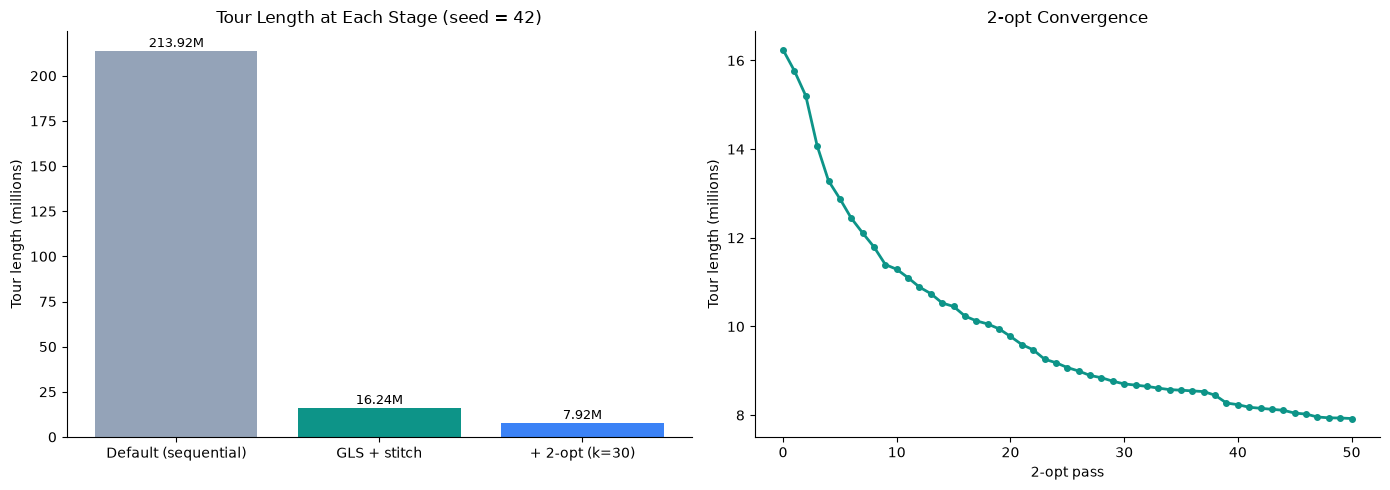

Final Summary:
  Default (sequential)         213,920,969   (  0.0% shorter than default)
  GLS + stitch                  16,241,548   ( 92.4% shorter than default)
  + 2-opt (k=30)                 7,924,262   ( 96.3% shorter than default)
  2-opt gain over stitched tour: 51.2%  (50 passes)

Timings (s): {'k-means': 15.6, 'intra-cluster': 933.2, 'cluster ordering': 26.1, '2-opt': 446.6}


In [13]:
# All numbers below come from `result` (Section 11) — nothing is hard-coded.
stages = result["stages"]
names = list(stages.keys())
vals = np.array(list(stages.values()))
base = vals[0]
savings = np.array(result["pass_savings"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tour length at each stage
colors = ["#94A3B8", "#0D9488", "#3B82F6"][:len(names)]
bars = axes[0].bar(names, vals / 1e6, color=colors)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v / 1e6 + 2, f"{v/1e6:.2f}M", ha="center", fontsize=9)
axes[0].set_ylabel("Tour length (millions)")
axes[0].set_title(f"Tour Length at Each Stage (seed = {result['seed']})")
axes[0].spines[["top", "right"]].set_visible(False)

# Right: 2-opt convergence (tour length after each pass)
if len(savings):
    after_pass = vals[1] - np.cumsum(savings)
    x = np.arange(0, len(savings) + 1)
    axes[1].plot(x, np.concatenate([[vals[1]], after_pass]) / 1e6, "o-", color="#0D9488", lw=2, ms=4)
    axes[1].set_xlabel("2-opt pass")
    axes[1].set_ylabel("Tour length (millions)")
    axes[1].set_title("2-opt Convergence")
    axes[1].spines[["top", "right"]].set_visible(False)
else:
    axes[1].axis("off")

plt.tight_layout()
plt.savefig("tour_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

print("Final Summary:")
for name, v in stages.items():
    print(f"  {name:<24} {v:>15,.0f}   ({(base - v) / base * 100:5.1f}% shorter than default)")
if len(vals) >= 3:
    print(f"  2-opt gain over stitched tour: {(vals[1] - vals[2]) / vals[1] * 100:.1f}%  "
          f"({len(savings)} passes)")
print("\nTimings (s):", {k: round(v, 1) for k, v in result["timings"].items()})